In [103]:
import torch
import numpy as np
import pandas as pd
import scanpy as sc
from typing import Optional, Union, Dict
import matplotlib.pyplot as plt

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [104]:
class SingleCellDataset(Dataset):
    def __init__(self, data: np.ndarray):
        self.data = torch.from_numpy(adata.X.toarray())
    
    def __len__(self):
        return self.data.shape[0]
    
    def __getitem__(self, idx):
        return self.data[idx]

class Autoencoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 32,
                 hidden_dims: Optional[list] = None,
                 dropout: float = 0.0,
                 use_batchnorm: bool = False,
                 final_activation: Optional[str] = None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [512, 256]

        encoder_layers = []
        in_dim = input_dim
        for h in hidden_dims:
            encoder_layers.append(nn.Linear(in_dim, h))
            if use_batchnorm:
                encoder_layers.append(nn.BatchNorm1d(h))
            encoder_layers.append(nn.ReLU())
            if dropout > 0:
                encoder_layers.append(nn.Dropout(dropout))
            in_dim = h
        encoder_layers.append(nn.Linear(in_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers = []
        in_dim = latent_dim
        for h in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(in_dim, h))
            if use_batchnorm:
                decoder_layers.append(nn.BatchNorm1d(h))
            decoder_layers.append(nn.ReLU())
            if dropout > 0:
                decoder_layers.append(nn.Dropout(dropout))
            in_dim = h
        decoder_layers.append(nn.Linear(in_dim, input_dim))
        if final_activation == 'softplus':
            decoder_layers.append(nn.Softplus())
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x: torch.Tensor):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

In [105]:
adata = sc.read_h5ad("/home/icb/alessandro.palma/environment/scExpDesign-Reproducibility/project_folder/datasets/combosciplex/combosciplex.h5ad")

In [106]:
adata.X.toarray()
adata = adata[:, adata.var.highly_variable]

In [107]:
dataset = SingleCellDataset(adata)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

In [108]:
model = Autoencoder(input_dim=adata.shape[1], 
                    latent_dim=5,
                    hidden_dims=[256, 256, 256], 
                    final_activation="linear")
model = model.to("cuda")

In [109]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
criterion = nn.MSELoss()

In [110]:
history = []
for epoch in range(100):
    model.train()
    running_loss = 0.0
    n_batches = 0
    for batch in dataloader:
        batch = batch.to("cuda")
        optimizer.zero_grad()
        recon, _ = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches += 1

    train_loss = running_loss / (n_batches if n_batches > 0 else 1)
    history.append(train_loss)
    print(f"Epoch {epoch}/{200}  loss={train_loss:.6f}")

Epoch 0/200  loss=0.120074
Epoch 1/200  loss=0.108949
Epoch 2/200  loss=0.107374
Epoch 3/200  loss=0.106305
Epoch 4/200  loss=0.105730
Epoch 5/200  loss=0.105428
Epoch 6/200  loss=0.105246
Epoch 7/200  loss=0.105070
Epoch 8/200  loss=0.104937
Epoch 9/200  loss=0.104819
Epoch 10/200  loss=0.104713
Epoch 11/200  loss=0.104626
Epoch 12/200  loss=0.104545
Epoch 13/200  loss=0.104480
Epoch 14/200  loss=0.104443
Epoch 15/200  loss=0.104354
Epoch 16/200  loss=0.104305
Epoch 17/200  loss=0.104261
Epoch 18/200  loss=0.104244
Epoch 19/200  loss=0.104176
Epoch 20/200  loss=0.104134
Epoch 21/200  loss=0.104097
Epoch 22/200  loss=0.104072
Epoch 23/200  loss=0.104035
Epoch 24/200  loss=0.104005
Epoch 25/200  loss=0.103971
Epoch 26/200  loss=0.103933
Epoch 27/200  loss=0.103901
Epoch 28/200  loss=0.103890
Epoch 29/200  loss=0.103847
Epoch 30/200  loss=0.103825
Epoch 31/200  loss=0.103798
Epoch 32/200  loss=0.103777
Epoch 33/200  loss=0.103741
Epoch 34/200  loss=0.103736
Epoch 35/200  loss=0.103713
Ep

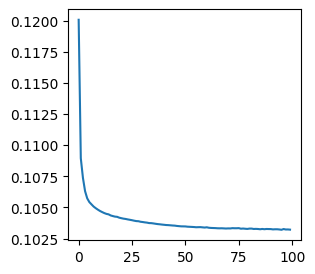

In [111]:
plt.figure(figsize=(3,3))
plt.plot(history)

In [112]:
real = []
reconstructed = []

with torch.no_grad():
    for b in dataloader:
        b = b.to("cuda")
        b_hat = model(b)[0]
        real.append(b.cpu().numpy())
        reconstructed.append(b_hat.cpu().numpy())

In [113]:
real = np.concatenate(real)
reconstructed = np.concatenate(reconstructed)

In [114]:
obs = pd.DataFrame({"data_type": ["real" for _ in range(len(real))]+["reconstructed" for _ in range(len(reconstructed))]})
adata_recon = sc.AnnData(X=np.concatenate([real, reconstructed], axis=0),
                        obs=obs)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [115]:
sc.tl.pca(adata_recon)
sc.pp.neighbors(adata_recon)
sc.tl.umap(adata_recon)

In [ ]:
sc.pl.umap(adata_recon, color="data_type")

In [ ]:
model